In [1]:
import sys
import json
sys.path.append('..')
from Main.Experiment_class import *
from copy import deepcopy

In [2]:
markersize = 15
capsize = 6
capthick = 2
linewidth = 7.5
elinewidth=2

In [3]:
obj = PIcode_experiment(None, False, False)
obj.load('../Data/31st_August_Torino_run1.json')
N = obj.storage['multi_qec_30_1']['shots']
rec_time = obj.recovery_time*obj.dt/1e3
enc_time = obj.encoder_time*obj.dt/1e3

In [4]:
with open('../Data/bare_qubit_datas.json', 'r') as f:
    bare_qubit_storage = json.load(f)

Set 1 -> [57, 58, 59, 60, 61] -> Index: 4 \
Set 2 -> [32, 33, 37, 52, 51] -> Index: 5 \
Set 3 -> [102, 101, 111, 120, 121] -> Index: 6

In [9]:
index = 4
qubit_set = obj.storage['multi_qec_30_1']['qubit_pos'][index]

In [10]:
fids_bare = []
fids_bare_stds = []
delays = np.array(obj.storage['bare_qubit']['delays'])
for delay in delays:
    datas = []
    for qubit in qubit_set:
        datas += bare_qubit_storage[str(qubit)][str(delay)]
    fids_bare.append(np.mean(datas))
    fids_bare_stds.append(np.std(datas))
fids_bare = np.array(fids_bare)
fids_bare_stds = np.array(fids_bare_stds)

In [11]:
delays_multi = deepcopy(delays)
relaxation_time = 30
for i in range(len(delays_multi)):
    t = int(np.ceil(delays_multi[i]/30))
    if t  == 0:
        t = 1
    delays_multi[i] += t*rec_time
delays_multi += 2*enc_time

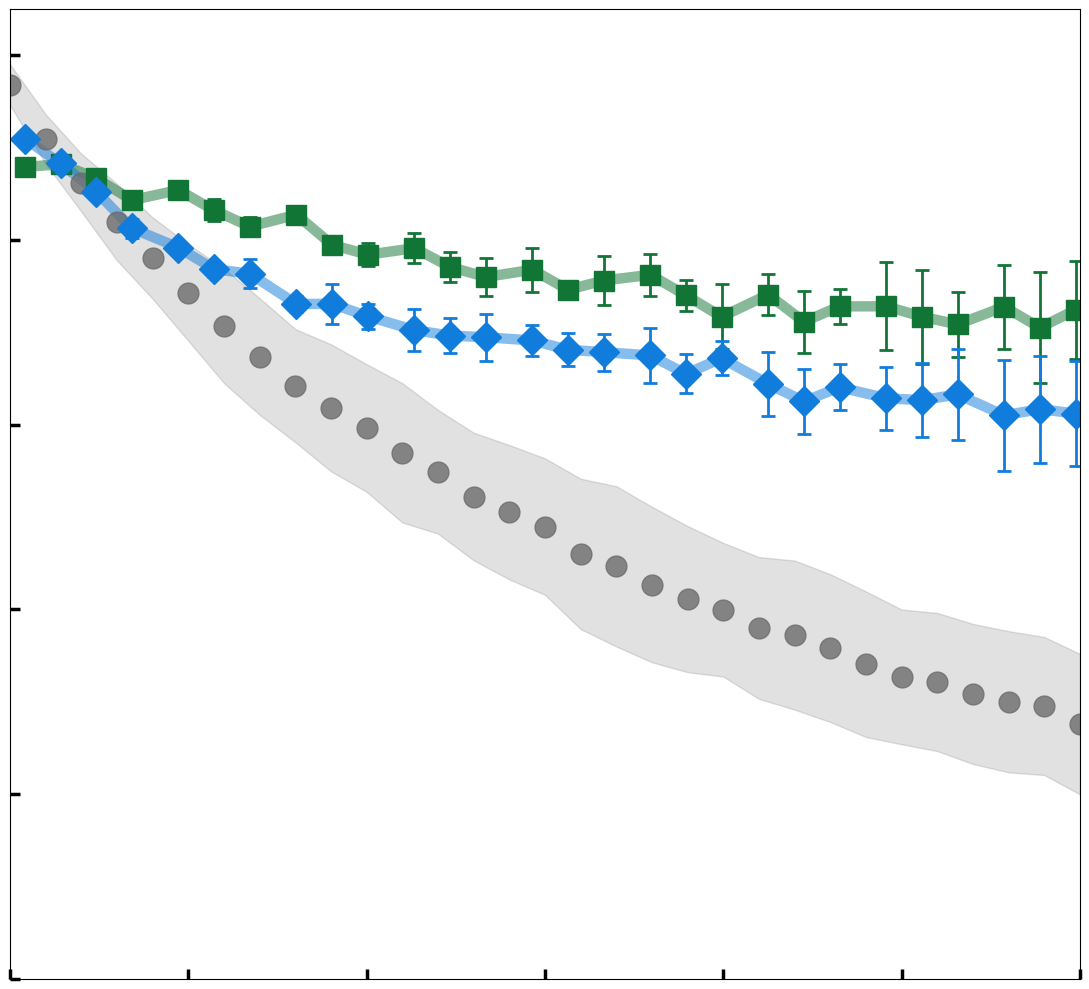

In [12]:
plt.figure(figsize=(11,10))
plt.errorbar(delays, fids_bare, yerr=None, 
            fmt='o', color='#6C6C6C', ecolor = '#6C6C6C', markersize=markersize, 
            capsize=5, capthick=2, elinewidth=elinewidth, 
            label='Bare_qubit', ls = None, alpha = 0.8)
# plt.plot(delays, fids_bare, color='black', linewidth = linewidth, alpha = 0.2)
# plt.plot(delays, fids_bare, color='black', label='Bare_qubit', ls = None, marker='o', markersize=6)
plt.fill_between(delays, fids_bare-fids_bare_stds, fids_bare+fids_bare_stds, alpha=0.2, color="#6C6C6C")
plt.errorbar(delays_multi[:-3], obj.storage[f'multi_qec_30_0']['fids'][f'{index}'][:-3], yerr=obj.storage[f'multi_qec_30_0']['fids_stds'][f'{index}'][:-3], 
            fmt='s', color="#117535", ecolor = "#117535", markersize=markersize, 
            capsize=5, capthick=2, elinewidth=elinewidth, 
            label=r'$|0_L \rangle$ Multi QEC (30 μs)', ls = None)
plt.plot(delays_multi[:-3], obj.storage[f'multi_qec_30_0']['fids'][f'{index}'][:-3], color='#117535', linewidth = linewidth, alpha = 0.5)

plt.errorbar(delays_multi[:-3], obj.storage[f'multi_qec_30_1']['fids'][f'{index}'][:-3], yerr=obj.storage[f'multi_qec_30_1']['fids_stds'][f'{index}'][:-3], 
            fmt='D', color='#107DDD', ecolor = '#107DDD', markersize=markersize, 
            capsize=5, capthick=2, elinewidth=elinewidth, 
            label=r'$|1_L \rangle$ Multi QEC (30 μs)', ls = None)
plt.plot(delays_multi[:-3], obj.storage[f'multi_qec_30_1']['fids'][f'{index}'][:-3], color='#107DDD', linewidth = linewidth, alpha = 0.5)
plt.xlim(0, 300)
plt.ylim(0, 1.05)
plt.tick_params(axis='both', direction='in', labelsize = 0, width = 2.5, size = 7.5, labelbottom = False, labelleft = False)
# plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5)
# plt.xlabel('Total Evolution Time [μs]', fontsize = 24)
# plt.ylabel(r'${Fidelity}^2$', fontsize = 24)
# plt.legend(loc = 'lower left', frameon = False, fontsize = 24)
plt.tight_layout()
plt.savefig('fig4_a_empty.pdf', bbox_inches='tight', pad_inches=0, dpi = 300)